In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [17]:
dane00=pd.read_csv('pokemon_data.csv')
sorted_types = sorted(dane00['type1'].unique())
median_order = dane00.groupby('type1')['total'].median().sort_values().index

In [18]:
#..ZMIANA - TWORZENIE WŁASNEJ PALETY
GRAY_COLOR = 'lightgray'  
STRONG_COLOR = '#e99346' 
WEAK_COLOR = '#2596be'   

n_highlight = 3 #..ile skrzypiec z każdego końca podkreślić
weakest_types = median_order[:n_highlight]
strongest_types = median_order[-n_highlight:]

#..tworzenie palety kolorów
custom_palette = {type_name: GRAY_COLOR for type_name in median_order}
for type_name in strongest_types: custom_palette[type_name] = STRONG_COLOR
for type_name in weakest_types: custom_palette[type_name] = WEAK_COLOR

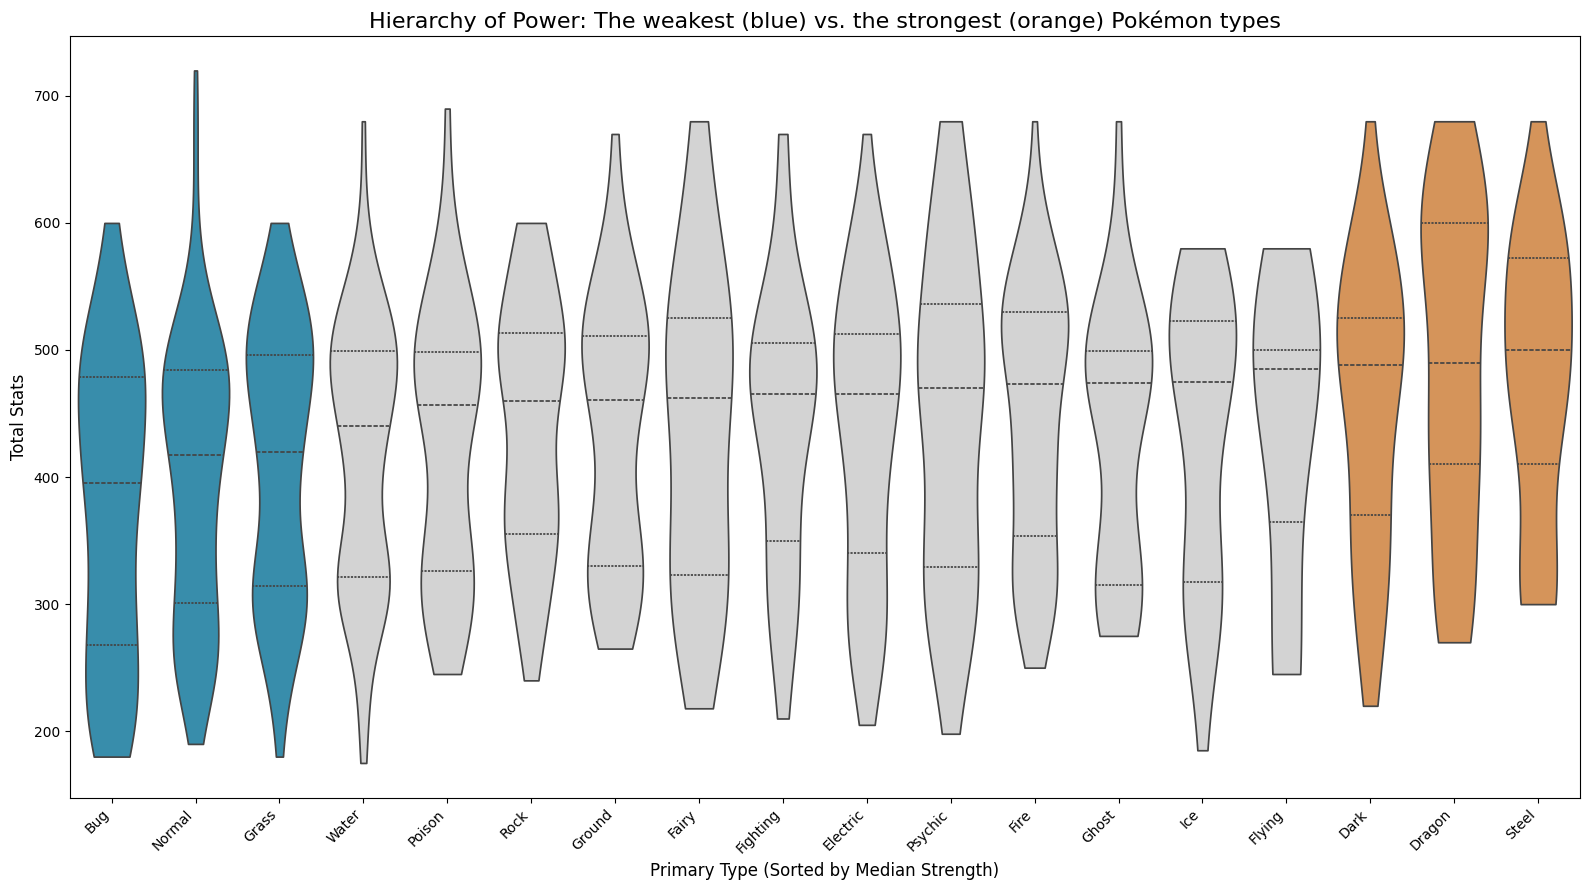

In [20]:

plt.figure(figsize=(16, 9))

sns.violinplot(data=dane00,
               x='type1',
               y='total',
               palette=custom_palette, #..własne kolory
               inner='quartile', #..Pokazuje w środku medianę i kwartyle
               cut=0, #..skrzypce kończą się dokładnie na najniższej i najwyższej wartości w danych
               order=median_order, #..sortowanie przez medianę
               )

#..ZMIANA - tytuł tłumaczący kolory
plt.title('Hierarchy of Power: The weakest (blue) vs. the strongest (orange) Pokémon types', fontsize=16)
plt.xlabel('Primary Type (Sorted by Median Strength)', fontsize=12) #..ZMIANA NAZWY OSI
plt.ylabel('Total Stats', fontsize=12)
plt.xticks(rotation=45, ha='right')


plt.tight_layout()
plt.savefig('violin.png')
plt.show()